In [1]:
# OK, now let's verify Installation
# Run these commands to ensure both are installed correctly.
import tensorflow as tf
print('tensorflow verion: ', tf.__version__)
import sklearn
print('scikit-learn version: ', sklearn.__version__)

tensorflow verion:  2.20.0
scikit-learn version:  1.8.0


In [2]:
# ==========================================
# Load MNIST dataset
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets
# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data() # Load MNIST dataset, seperate into training and testing sets
# Normalise pixel values to [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Now before moving on, let's explore the dataset and visualise the data
# Find number of classes (unique numbers of the train labels)
classes = np.unique(y_train)
print('Number of classes: ', len(classes))
print('Output classes: ', classes)
# Find number of training data and data shape
print('Number of training data: ', len(x_train))
x_train.shape



Number of classes:  10
Output classes:  [0 1 2 3 4 5 6 7 8 9]
Number of training data:  60000


(60000, 28, 28)

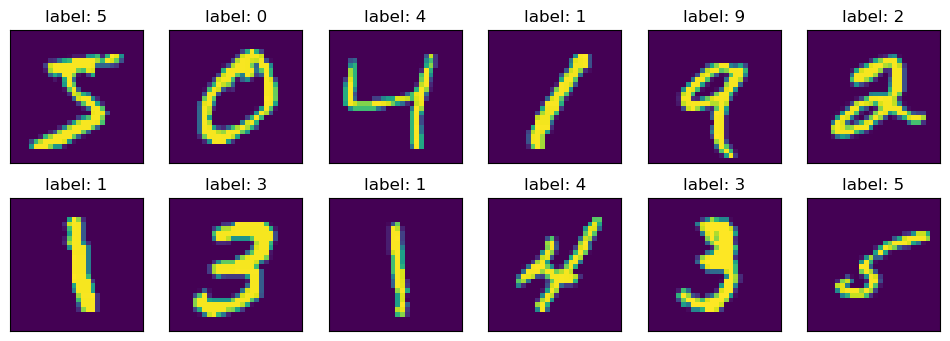

In [4]:
# Visualise some images
plt.figure(figsize=(12, 4))
for i in range(12): # show 12 images
    plt.subplot(2, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.title('label: '+str(y_train[i])) # label
plt.show()

In [7]:
# ==========================================
# Extract HOG Features
# ==========================================

from skimage.feature import hog

# Define our HOG feature extraction function
def extract_hog(images):
        features = [] # list to store HOG features
        for img in images: #loop through each image
            hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
            )
            features.append(hog_feat)
        return np.array(features)
# Extract HOG features for the train and test sets
X_train_hog = extract_hog(x_train[:])
X_test_hog = extract_hog(x_test[:])

In [8]:
# ==========================================
# Train SVM Classifier
# ==========================================
# We'll use a linear kernel for efficiency, but feel free to use non-linear kernels in your own code
from sklearn import svm
clf_hog = svm.SVC(kernel='linear')
clf_hog.fit(X_train_hog, y_train) #train the SVM classifier with the HOG features and labels from the training set

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


HOG + SVM Accuracy: 0.9767


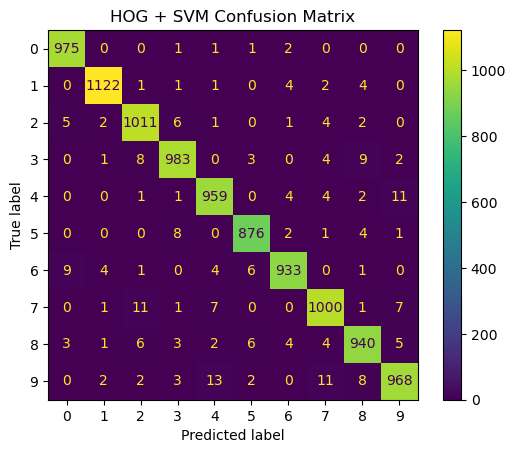

In [9]:
# ==========================================
# Evaluate Performance
# ==========================================
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Use the trained SVM classifier for prediction on test set
y_pred_hog = clf_hog.predict(X_test_hog)
# Compute and print accuracy
print("HOG + SVM Accuracy:", accuracy_score(y_test, y_pred_hog))
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_hog)
ConfusionMatrixDisplay(cm).plot()
plt.title("HOG + SVM Confusion Matrix")
plt.show()

In [12]:
import cv2

sift = cv2.SIFT_create() #create a SIFT feature extractor object

#Sift feature exctraction
def extract_shift(images):
    descriptors_list = []
    for img in images: 
        img_uint8 = (img*255).astype('uint8') # Convert the image to uint8 format
        _, descriptors = sift.detectAndCompute(img_uint8, None) #detect keypoints and compute descriptors
        if descriptors is not None: #check if descriptors were found
            descriptors_list.extend(descriptors)
    return np.array(descriptors_list)

sift_descriptors = extract_shift(x_train[:1000])


In [26]:
# ==========================================
# Build Visual Vocabulary (K-Means)
# ==========================================
from sklearn.cluster import MiniBatchKMeans
k = 50
kmeans = MiniBatchKMeans(n_clusters=k, random_state=0)
kmeans.fit(sift_descriptors)

# Define the function for BoVW representations
def build_histogram(images, kmeans):
    histograms = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        _, descriptors = sift.detectAndCompute(img_uint8, None)
        hist = np.zeros(k)
        if descriptors is not None:
            clusters = kmeans.predict(descriptors)
        for c in clusters:
            hist[c] += 1
        histograms.append(hist)
    return np.array(histograms)

X_train_sift = build_histogram(x_train[:10000], kmeans)
X_test_sift = build_histogram(x_test[:2000], kmeans)
y_train_sift = y_train[:10000]
y_test_sift = y_test[:2000]

print(f" {X_train_sift.shape} {y_train_sift.shape} {X_test_sift.shape} {y_test_sift.shape}")

c:\Users\u3263629\.conda\envs\Ramiasaad\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


 (10000, 50) (10000,) (2000, 50) (2000,)


SIFT + SVM Accuracy: 0.537


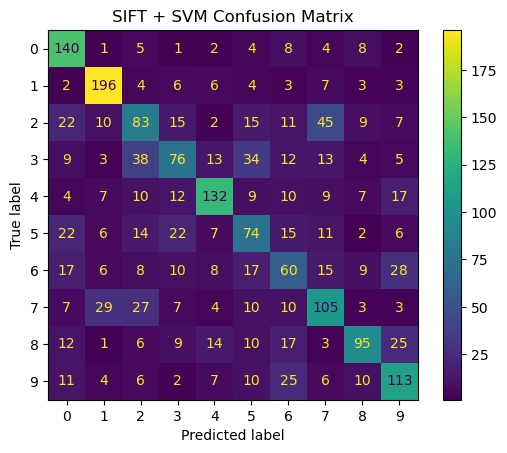

In [27]:
# ==========================================
# Train SVM and Evaluate
# ==========================================
# Train an SVM (linear kernel)
clf_sift = svm.SVC(kernel='linear')
clf_sift.fit(X_train_sift, y_train_sift)
# Prediction
y_pred_sift = clf_sift.predict(X_test_sift)
# Accuracy
print("SIFT + SVM Accuracy:", accuracy_score(y_test_sift, y_pred_sift))
# Confusion matrix
cm = confusion_matrix(y_test_sift, y_pred_sift)
ConfusionMatrixDisplay(cm).plot()
plt.title("SIFT + SVM Confusion Matrix")
plt.show()

In [28]:
# ==========================================
# Prepare the Data
# ==========================================
# First, let's format the data correctly for CNN input. CNNs expect images with a channel dimension.
# MNIST images are grayscale, so we add the channel dimension
import numpy as np
# Add channel dimension: (28,28) → (28,28,1)
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]
print("Training shape:", x_train_cnn.shape)

Training shape: (60000, 28, 28, 1)


In [32]:
from tensorflow.keras import layers, models

model = models.Sequential([
# First convolution block
layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),
# Second convolution block
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
# Classification head
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')])

In [35]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# ==========================================
# Train the Model
# ==========================================
history = model.fit(
x_train_cnn,
y_train,
epochs=5,
batch_size=64,
validation_split=0.1 # use 0.1 of train set as validation set to monitor overfitting
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9483 - loss: 0.1706 - val_accuracy: 0.9832 - val_loss: 0.0544
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9841 - loss: 0.0515 - val_accuracy: 0.9882 - val_loss: 0.0427
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9867 - val_loss: 0.0452
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9892 - val_loss: 0.0345
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9936 - loss: 0.0197 - val_accuracy: 0.9898 - val_loss: 0.0409


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9892 - loss: 0.0345
CNN Test Accuracy: 0.9891999959945679
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


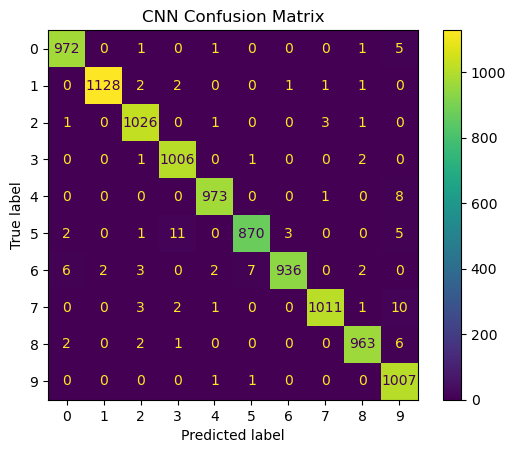

In [39]:
# ==========================================
# Evaluate the Model
# ==========================================
# Accuracy
test_loss, test_acc = model.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)
# Predictions on test set
y_pred_cnn = np.argmax(model.predict(x_test_cnn), axis=1)
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm).plot()
plt.title("CNN Confusion Matrix")
plt.show()


In [41]:
# Find indices where prediction is incorrect
incorrect_indices = np.where(y_pred_cnn != y_test)[0]
print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 108


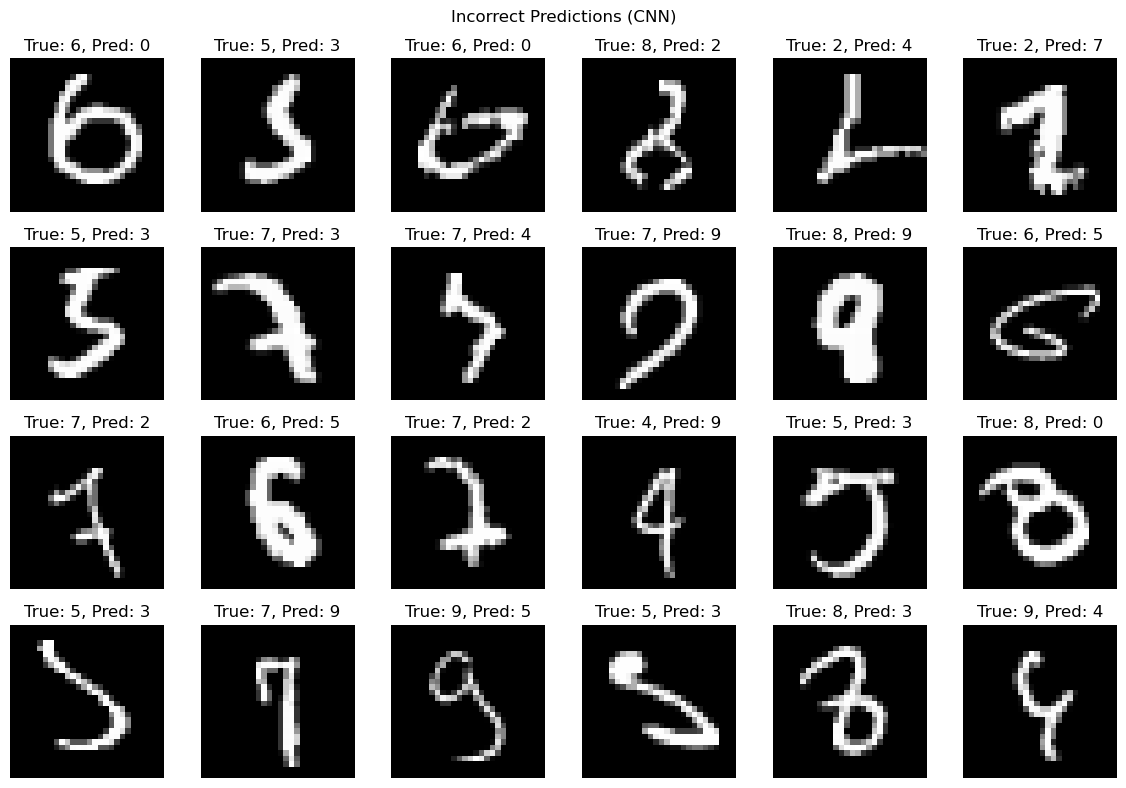

In [42]:
# Plot misclassified examples
plt.figure(figsize=(12, 8))
for i in range(24):
    idx = incorrect_indices[i]
    plt.subplot(4, 6, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_cnn[idx]}")
    plt.axis('off')
    plt.suptitle("Incorrect Predictions (CNN)")
    plt.tight_layout()
plt.show()